# Projet 2 : Analyse Big Data des ventes au détail
## Avec Apache Spark

**Contexte** : Analyse d'un jeu de données de ventes en détail (retailsale.csv) contenant plus de 1 million de lignes.

**Objectifs** :
- Utiliser Apache Spark pour traiter des données volumineuses
- Analyser l'impact des promotions, magasins et produits sur les ventes
- Construire un modèle de prédiction
- Formuler des recommandations stratégiques

---
## 1. Installation et configuration de Spark

On installe PySpark sur Colab (c'est déjà inclus mais on s'assure d'avoir la bonne version).

In [1]:
# Installation de PySpark
!pip install pyspark -q

In [2]:
# Imports
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *
from pyspark.ml.feature import VectorAssembler, StringIndexer
from pyspark.ml.regression import LinearRegression, RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml import Pipeline

# Pour les visualisations (on convertit en pandas pour les graphiques)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration des graphiques
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

import warnings
warnings.filterwarnings('ignore')

print("Imports OK !")

Imports OK !


In [3]:
# Création de la session Spark
# On alloue assez de mémoire pour traiter notre fichier de 1 million de lignes
spark = SparkSession.builder \
    .appName("Projet2_RetailSales") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

# Vérification
print(f"Spark version : {spark.version}")
print("Session Spark créée avec succès !")

Spark version : 4.0.1
Session Spark créée avec succès !


---
## 2. Chargement et exploration des données

In [4]:
# Chargement du fichier CSV avec Spark
df = spark.read.csv('retailsale.csv', header=True, inferSchema=True)

# Dimensions du dataset
nb_lignes = df.count()
nb_colonnes = len(df.columns)
print(f"Le dataset contient {nb_lignes:,} lignes et {nb_colonnes} colonnes.")
print(f"\nC'est bien du Big Data ! Plus de 1 million d'enregistrements.")

Le dataset contient 1,033,434 lignes et 10 colonnes.

C'est bien du Big Data ! Plus de 1 million d'enregistrements.


In [5]:
# Aperçu des premières lignes
df.show(10)

+----------+--------+--------+-----+-------+-----+-----+------------+-----------+------------+
|product_id|store_id|    date|sales|revenue|stock|price|promo_type_1|promo_bin_1|promo_type_2|
+----------+--------+--------+-----+-------+-----+-----+------------+-----------+------------+
|     P0001|   S0002|1/2/2017|  0.0|    0.0|    8| 6.25|        PR14|       NULL|        PR03|
|     P0001|   S0012|1/2/2017|  1.0|    5.3|    0| 6.25|        PR14|       NULL|        PR03|
|     P0001|   S0013|1/2/2017|  2.0|  10.59|    0| 6.25|        PR14|       NULL|        PR03|
|     P0001|   S0023|1/2/2017|  0.0|    0.0|    6| 6.25|        PR14|       NULL|        PR03|
|     P0001|   S0025|1/2/2017|  0.0|    0.0|    1| 6.25|        PR14|       NULL|        PR03|
|     P0001|   S0027|1/2/2017|  0.0|    0.0|    7| 6.25|        PR14|       NULL|        PR03|
|     P0001|   S0040|1/2/2017|  0.0|    0.0|   19| 6.25|        PR14|       NULL|        PR03|
|     P0001|   S0049|1/2/2017|  0.0|    0.0|    8|

In [6]:
# Schéma des données (types de chaque colonne)
print("Structure du dataset :\n")
df.printSchema()

Structure du dataset :

root
 |-- product_id: string (nullable = true)
 |-- store_id: string (nullable = true)
 |-- date: string (nullable = true)
 |-- sales: double (nullable = true)
 |-- revenue: double (nullable = true)
 |-- stock: integer (nullable = true)
 |-- price: double (nullable = true)
 |-- promo_type_1: string (nullable = true)
 |-- promo_bin_1: string (nullable = true)
 |-- promo_type_2: string (nullable = true)



### Description des variables

| Variable | Type initial | Type après conversion | Description |
|----------|--------------|----------------------|-------------|
| product_id | string | string | Identifiant unique du produit |
| store_id | string | string | Identifiant unique du magasin |
| date | string | **date** | Date de la transaction (convertie en format date) |
| sales | double | double | Nombre d'unités vendues |
| revenue | double | double | Revenu généré |
| stock | integer | integer | Niveau de stock disponible |
| price | double | double | Prix unitaire du produit |
| promo_type_1 | string | string | Type de promotion principale |
| promo_bin_1 | string | **supprimée** | Remplacée par promo_active (0/1) |
| promo_type_2 | string | string | Type de promotion secondaire |

**Note** : La colonne `date` est chargée comme string puis convertie en type date. La colonne `promo_bin_1` est transformée en `promo_active` (indicateur binaire 0/1).

In [7]:
# Statistiques descriptives de base
print("Statistiques descriptives :\n")
df.describe().show()

Statistiques descriptives :

+-------+----------+--------+---------+-----------------+------------------+------------------+------------------+------------+-----------+------------+
|summary|product_id|store_id|     date|            sales|           revenue|             stock|             price|promo_type_1|promo_bin_1|promo_type_2|
+-------+----------+--------+---------+-----------------+------------------+------------------+------------------+------------+-----------+------------+
|  count|   1033434| 1033434|  1033434|          1033434|           1033434|           1033434|           1033434|     1033434|     119165|     1033434|
|   mean|      NULL|    NULL|     NULL| 0.59282205733506|1.9051499853884284|16.499048802342482|  9.25275269636992|        NULL|       NULL|        NULL|
| stddev|      NULL|    NULL|     NULL|43.12450267634285| 89.84362737524752|42.496198192626544|11.359639682483742|        NULL|       NULL|        NULL|
|    min|     P0001|   S0001|1/10/2017|              

---
## 3. Prétraitement des données

On va nettoyer les données, traiter les valeurs manquantes et créer de nouvelles variables.

### 3.1 Identification des valeurs manquantes

In [8]:
# Compter les valeurs nulles par colonne
print("Valeurs manquantes par colonne :\n")

# On récupère les types de chaque colonne
types_colonnes = dict(df.dtypes)

for col_name in df.columns:
    # Pour les colonnes string, on vérifie aussi les chaînes vides
    if types_colonnes[col_name] == 'string':
        nb_null = df.filter(col(col_name).isNull() | (col(col_name) == "")).count()
    else:
        # Pour les colonnes numériques, on vérifie seulement les NULL
        nb_null = df.filter(col(col_name).isNull()).count()

    pct = (nb_null / nb_lignes) * 100
    if nb_null > 0:
        print(f"  {col_name}: {nb_null:,} ({pct:.2f}%)")

print("\nNote: promo_bin_1 contient des valeurs NULL (pas de promo active)")

Valeurs manquantes par colonne :

  promo_bin_1: 914,269 (88.47%)

Note: promo_bin_1 contient des valeurs NULL (pas de promo active)


**Interprétation** : La colonne `promo_bin_1` contient des valeurs vides, ce qui est normal car cela signifie qu'il n'y avait pas de promotion active. On va la traiter en la remplaçant par 0 (pas de promo).

### 3.2 Conversion et nettoyage des types

In [9]:
# Conversion de la date en format date
df_clean = df.withColumn("date", to_date(col("date"), "M/d/yyyy"))

# Traitement de promo_bin_1 : les valeurs vides deviennent 0, sinon 1
df_clean = df_clean.withColumn(
    "promo_active",
    when((col("promo_bin_1").isNull()) | (col("promo_bin_1") == ""), 0).otherwise(1)
)

# VERIFICATION : est-ce que la conversion de date a bien fonctionné ?
nb_dates_null = df_clean.filter(col("date").isNull()).count()
print(f"Dates NULL après conversion : {nb_dates_null}")

if nb_dates_null > 0:
    print("ATTENTION : Certaines dates n'ont pas été converties correctement !")
else:
    print("Toutes les dates ont été converties avec succès.")

# Affichage du nouveau schéma pour vérifier les types
print("\nSchéma après conversion :")
df_clean.printSchema()

# Vérification des premières lignes
df_clean.select("date", "promo_bin_1", "promo_active").show(5)

Dates NULL après conversion : 0
Toutes les dates ont été converties avec succès.

Schéma après conversion :
root
 |-- product_id: string (nullable = true)
 |-- store_id: string (nullable = true)
 |-- date: date (nullable = true)
 |-- sales: double (nullable = true)
 |-- revenue: double (nullable = true)
 |-- stock: integer (nullable = true)
 |-- price: double (nullable = true)
 |-- promo_type_1: string (nullable = true)
 |-- promo_bin_1: string (nullable = true)
 |-- promo_type_2: string (nullable = true)
 |-- promo_active: integer (nullable = false)

+----------+-----------+------------+
|      date|promo_bin_1|promo_active|
+----------+-----------+------------+
|2017-01-02|       NULL|           0|
|2017-01-02|       NULL|           0|
|2017-01-02|       NULL|           0|
|2017-01-02|       NULL|           0|
|2017-01-02|       NULL|           0|
+----------+-----------+------------+
only showing top 5 rows


In [10]:
# Vérification des valeurs aberrantes dans les colonnes numériques
print("Vérification des valeurs aberrantes :\n")

# Ventes négatives ?
ventes_neg = df_clean.filter(col("sales") < 0).count()
print(f"  Ventes négatives : {ventes_neg}")

# Prix négatifs ou nuls ?
prix_neg = df_clean.filter(col("price") <= 0).count()
print(f"  Prix <= 0 : {prix_neg}")

# Stock négatif ?
stock_neg = df_clean.filter(col("stock") < 0).count()
print(f"  Stock négatif : {stock_neg}")

# Revenue négatif ?
rev_neg = df_clean.filter(col("revenue") < 0).count()
print(f"  Revenue négatif : {rev_neg}")

Vérification des valeurs aberrantes :

  Ventes négatives : 0
  Prix <= 0 : 0
  Stock négatif : 0
  Revenue négatif : 0


**Interprétation** : Les données sont propres, pas de valeurs aberrantes détectées. Les ventes, prix, stock et revenue sont tous positifs ou nuls (normal pour des jours sans vente).

### 3.3 Création de nouvelles variables

In [11]:
# Extraction des composantes temporelles
df_clean = df_clean.withColumn("year", year(col("date"))) \
                   .withColumn("month", month(col("date"))) \
                   .withColumn("day_of_week", dayofweek(col("date"))) \
                   .withColumn("week_of_year", weekofyear(col("date")))

# Calcul du revenu théorique (ventes x prix) pour vérifier la cohérence
df_clean = df_clean.withColumn("revenue_calc", round(col("sales") * col("price"), 2))

# Indicateur de rupture de stock
df_clean = df_clean.withColumn(
    "rupture_stock",
    when(col("stock") == 0, 1).otherwise(0)
)

print("Nouvelles variables créées :")
print("  - year, month, day_of_week, week_of_year (temporel)")
print("  - revenue_calc (ventes x prix)")
print("  - promo_active (0 ou 1)")
print("  - rupture_stock (0 ou 1)")

Nouvelles variables créées :
  - year, month, day_of_week, week_of_year (temporel)
  - revenue_calc (ventes x prix)
  - promo_active (0 ou 1)
  - rupture_stock (0 ou 1)


In [12]:
# Aperçu des données nettoyées
df_clean.select("product_id", "store_id", "date", "sales", "revenue",
                "price", "promo_active", "year", "month").show(10)

+----------+--------+----------+-----+-------+-----+------------+----+-----+
|product_id|store_id|      date|sales|revenue|price|promo_active|year|month|
+----------+--------+----------+-----+-------+-----+------------+----+-----+
|     P0001|   S0002|2017-01-02|  0.0|    0.0| 6.25|           0|2017|    1|
|     P0001|   S0012|2017-01-02|  1.0|    5.3| 6.25|           0|2017|    1|
|     P0001|   S0013|2017-01-02|  2.0|  10.59| 6.25|           0|2017|    1|
|     P0001|   S0023|2017-01-02|  0.0|    0.0| 6.25|           0|2017|    1|
|     P0001|   S0025|2017-01-02|  0.0|    0.0| 6.25|           0|2017|    1|
|     P0001|   S0027|2017-01-02|  0.0|    0.0| 6.25|           0|2017|    1|
|     P0001|   S0040|2017-01-02|  0.0|    0.0| 6.25|           0|2017|    1|
|     P0001|   S0049|2017-01-02|  0.0|    0.0| 6.25|           0|2017|    1|
|     P0001|   S0050|2017-01-02|  0.0|    0.0| 6.25|           0|2017|    1|
|     P0001|   S0051|2017-01-02|  0.0|    0.0| 6.25|           0|2017|    1|

### 3.4 Justification du maintien des colonnes

**Colonnes conservées** :
- `product_id`, `store_id` : essentiels pour l'analyse par produit et magasin
- `date` et ses dérivées : analyse temporelle
- `sales`, `revenue`, `price` : variables clés de l'analyse
- `stock` : pour analyser l'impact du stock sur les ventes
- `promo_type_1`, `promo_type_2` : types de promotions
- `promo_active` : indicateur binaire simplifié

**Colonne retirée** :
- `promo_bin_1` : remplacée par `promo_active` (plus simple à utiliser)

In [13]:
# On supprime la colonne promo_bin_1 (remplacée par promo_active)
df_clean = df_clean.drop("promo_bin_1")

# Vérification du schéma final
print("Colonnes finales :\n")
for col_name in df_clean.columns:
    print(f"  - {col_name}")

Colonnes finales :

  - product_id
  - store_id
  - date
  - sales
  - revenue
  - stock
  - price
  - promo_type_1
  - promo_type_2
  - promo_active
  - year
  - month
  - day_of_week
  - week_of_year
  - revenue_calc
  - rupture_stock


---
## 4. Analyse exploratoire avec Apache Spark

### 4.1 Statistiques descriptives globales

In [14]:
# Statistiques globales sur les variables numériques
print("Statistiques descriptives globales :\n")
df_clean.select("sales", "revenue", "stock", "price").describe().show()

Statistiques descriptives globales :

+-------+-----------------+------------------+------------------+------------------+
|summary|            sales|           revenue|             stock|             price|
+-------+-----------------+------------------+------------------+------------------+
|  count|          1033434|           1033434|           1033434|           1033434|
|   mean| 0.59282205733506|1.9051499853884284|16.499048802342482|  9.25275269636992|
| stddev|43.12450267634285| 89.84362737524752|42.496198192626544|11.359639682483742|
|    min|              0.0|               0.0|                 0|              0.25|
|    max|          27656.0|          52496.85|              4655|             249.9|
+-------+-----------------+------------------+------------------+------------------+



In [15]:
# Résumé des données
print("Résumé du dataset :\n")

# Nombre de produits uniques
nb_produits = df_clean.select("product_id").distinct().count()
print(f"  Nombre de produits : {nb_produits}")

# Nombre de magasins
nb_magasins = df_clean.select("store_id").distinct().count()
print(f"  Nombre de magasins : {nb_magasins}")

# Période couverte
date_min = df_clean.agg(min("date")).collect()[0][0]
date_max = df_clean.agg(max("date")).collect()[0][0]
print(f"  Période : du {date_min} au {date_max}")

# Totaux
total_ventes = df_clean.agg(sum("sales")).collect()[0][0]
total_revenue = df_clean.agg(sum("revenue")).collect()[0][0]
print(f"  Total des ventes : {total_ventes:,.0f} unités")
print(f"  Total des revenus : {total_revenue:,.2f} €")

Résumé du dataset :

  Nombre de produits : 324
  Nombre de magasins : 107
  Période : du 2017-01-02 au 2017-03-21
  Total des ventes : 612,642 unités
  Total des revenus : 1,968,846.77 €


**Interprétation** : Le dataset couvre une période significative avec plusieurs produits et magasins. Cela nous donne une bonne base pour analyser les tendances et les performances.

### 4.2 Statistiques par sous-groupes

In [16]:
# Ventes et revenus par produit
print("Top 10 des produits par ventes :\n")
ventes_par_produit = df_clean.groupBy("product_id") \
    .agg(
        sum("sales").alias("total_ventes"),
        sum("revenue").alias("total_revenue"),
        avg("price").alias("prix_moyen")
    ) \
    .orderBy(col("total_ventes").desc())

ventes_par_produit.show(10)

Top 10 des produits par ventes :

+----------+------------+------------------+-------------------+
|product_id|total_ventes|     total_revenue|         prix_moyen|
+----------+------------+------------------+-------------------+
|     P0103|    122472.0|254597.93999999866| 2.6559808306707366|
|     P0438|     78075.0|17702.329999999914|               0.25|
|     P0051|     26381.0|16782.559999999794| 0.6999999999999695|
|     P0364|     23065.0|20596.950000000455|                1.0|
|     P0590|     19334.0| 8694.909999999976|0.49050392504431817|
|     P0129|     13106.0| 295934.5900000017|  26.66322727848759|
|     P0569|     12659.0|          30461.95|  2.602836185819045|
|     P0333|     11697.0|19883.819999999985| 1.8548647996138306|
|     P0664|     10783.0|12380.349999999962|               1.25|
|     P0261|      9501.0|36815.989999999576|  4.464995777536576|
+----------+------------+------------------+-------------------+
only showing top 10 rows


In [17]:
# Ventes et revenus par magasin
print("Top 10 des magasins par revenus :\n")
ventes_par_magasin = df_clean.groupBy("store_id") \
    .agg(
        sum("sales").alias("total_ventes"),
        sum("revenue").alias("total_revenue"),
        count("*").alias("nb_transactions")
    ) \
    .orderBy(col("total_revenue").desc())

ventes_par_magasin.show(10)

Top 10 des magasins par revenus :

+--------+------------------+------------------+---------------+
|store_id|      total_ventes|     total_revenue|nb_transactions|
+--------+------------------+------------------+---------------+
|   S0097| 98847.14000000001|247042.62000000034|          17406|
|   S0085|37937.729999999996|117882.50000000003|          19140|
|   S0062|18316.819999999996| 95943.76000000004|          16590|
|   S0095|13798.260000000004|  86527.6600000001|          11292|
|   S0026|          19473.19| 82572.54999999992|          16661|
|   S0020|18188.020000000004| 69049.52000000002|          16044|
|   S0038|22120.030000000002| 51650.19999999987|          19805|
|   S0104|11676.569999999996|39348.269999999786|          16129|
|   S0040|           9843.92| 33434.97999999984|          14835|
|   S0031|          10344.65|32303.399999999914|          16499|
+--------+------------------+------------------+---------------+
only showing top 10 rows


In [18]:
# Impact des promotions
print("Statistiques avec et sans promotion :\n")
stats_promo = df_clean.groupBy("promo_active") \
    .agg(
        count("*").alias("nb_lignes"),
        sum("sales").alias("total_ventes"),
        avg("sales").alias("ventes_moyennes"),
        sum("revenue").alias("total_revenue")
    )

stats_promo.show()

Statistiques avec et sans promotion :

+------------+---------+------------+------------------+------------------+
|promo_active|nb_lignes|total_ventes|   ventes_moyennes|     total_revenue|
+------------+---------+------------+------------------+------------------+
|           1|   119165|    64900.81|0.5446297990181681| 486423.4400000275|
|           0|   914269|   547741.66| 0.599103392983903|1482423.3300000061|
+------------+---------+------------+------------------+------------------+



**Interprétation des promotions** :

Surprise ! Les résultats montrent que les ventes moyennes sont **légèrement plus élevées sans promotion** (0.60) qu'avec promotion (0.54). Cela peut s'expliquer par :
- Les promotions ciblent peut-être des produits qui se vendent déjà mal
- La période d'analyse (3 mois) est peut-être trop courte pour voir l'effet réel
- Les promotions actives (seulement 11.5% des transactions) ne sont pas assez ciblées

C'est un résultat contre-intuitif qui mérite une analyse plus approfondie.

### 4.3 Distribution des ventes et revenus

In [19]:
# Distribution des ventes (quantiles)
print("Distribution des ventes (quantiles) :\n")
quantiles_ventes = df_clean.approxQuantile("sales", [0.25, 0.5, 0.75, 0.9, 0.95, 0.99], 0.01)
print(f"  25% : {quantiles_ventes[0]}")
print(f"  50% (médiane) : {quantiles_ventes[1]}")
print(f"  75% : {quantiles_ventes[2]}")
print(f"  90% : {quantiles_ventes[3]}")
print(f"  95% : {quantiles_ventes[4]}")
print(f"  99% : {quantiles_ventes[5]}")

Distribution des ventes (quantiles) :

  25% : 0.0
  50% (médiane) : 0.0
  75% : 0.0
  90% : 1.0
  95% : 3.0
  99% : 27656.0


In [20]:
# Distribution des revenus
print("Distribution des revenus (quantiles) :\n")
quantiles_rev = df_clean.approxQuantile("revenue", [0.25, 0.5, 0.75, 0.9, 0.95, 0.99], 0.01)
print(f"  25% : {quantiles_rev[0]:.2f}")
print(f"  50% (médiane) : {quantiles_rev[1]:.2f}")
print(f"  75% : {quantiles_rev[2]:.2f}")
print(f"  90% : {quantiles_rev[3]:.2f}")
print(f"  95% : {quantiles_rev[4]:.2f}")
print(f"  99% : {quantiles_rev[5]:.2f}")

Distribution des revenus (quantiles) :

  25% : 0.00
  50% (médiane) : 0.00
  75% : 0.00
  90% : 3.89
  95% : 8.80
  99% : 52496.85


**Interprétation** : La médiane des ventes est probablement basse (beaucoup de lignes avec 0 ventes), ce qui est normal dans le retail. La majorité des revenus sont générés par une minorité de transactions.

### 4.4 Corrélations

In [21]:
# Calcul des corrélations entre variables numériques
print("Corrélations entre les variables :\n")

# Prix vs Ventes
corr_prix_ventes = df_clean.stat.corr("price", "sales")
print(f"  Prix vs Ventes : {corr_prix_ventes:.4f}")

# Stock vs Ventes
corr_stock_ventes = df_clean.stat.corr("stock", "sales")
print(f"  Stock vs Ventes : {corr_stock_ventes:.4f}")

# Promo vs Ventes
corr_promo_ventes = df_clean.stat.corr("promo_active", "sales")
print(f"  Promo vs Ventes : {corr_promo_ventes:.4f}")

# Prix vs Revenue
corr_prix_rev = df_clean.stat.corr("price", "revenue")
print(f"  Prix vs Revenue : {corr_prix_rev:.4f}")

Corrélations entre les variables :

  Prix vs Ventes : -0.0065
  Stock vs Ventes : 0.0285
  Promo vs Ventes : -0.0004
  Prix vs Revenue : 0.0084


**Interprétation des corrélations** :

Les corrélations sont toutes très faibles (proches de 0), ce qui indique des relations linéaires peu marquées :
- **Prix vs Ventes (-0.0065)** : Très légèrement négative, les produits moins chers se vendent un peu mieux
- **Stock vs Ventes (0.0285)** : Légèrement positive, avoir du stock aide à vendre
- **Promo vs Ventes (-0.0004)** : Quasi nulle, les promotions n'ont pas d'impact linéaire visible sur les ventes

Ces faibles corrélations suggèrent que les relations entre ces variables sont plus complexes (non-linéaires) ou que d'autres facteurs non mesurés jouent un rôle important.

### 4.5 Tendances et anomalies

In [22]:
# Évolution mensuelle des ventes
print("Évolution mensuelle des ventes :\n")
ventes_mensuelles = df_clean.groupBy("year", "month") \
    .agg(
        sum("sales").alias("total_ventes"),
        sum("revenue").alias("total_revenue")
    ) \
    .orderBy("year", "month")

ventes_mensuelles.show(20)

Évolution mensuelle des ventes :

+----+-----+------------------+------------------+
|year|month|      total_ventes|     total_revenue|
+----+-----+------------------+------------------+
|2017|    1|202464.21000000008| 811569.4299999829|
|2017|    2| 266362.8699999998| 713090.2800000056|
|2017|    3|143815.38999999996|444187.05999998027|
+----+-----+------------------+------------------+



In [23]:
# Détection d'anomalies : jours avec ventes exceptionnellement élevées
print("Top 10 des jours avec le plus de ventes :\n")
ventes_jour = df_clean.groupBy("date") \
    .agg(sum("sales").alias("total_ventes")) \
    .orderBy(col("total_ventes").desc())

ventes_jour.show(10)

Top 10 des jours avec le plus de ventes :

+----------+------------------+
|      date|      total_ventes|
+----------+------------------+
|2017-02-24|          33998.67|
|2017-02-27|33662.189999999995|
|2017-02-08|19968.859999999982|
|2017-02-02|19800.359999999997|
|2017-01-21|12212.510000000004|
|2017-01-20|11526.479999999998|
|2017-03-11|10081.330000000002|
|2017-03-12|           9820.89|
|2017-02-12| 8695.210000000003|
|2017-02-11| 8682.669999999998|
+----------+------------------+
only showing top 10 rows


**Interprétation** : Les pics de ventes correspondent souvent à des périodes de promotion ou des événements spéciaux (soldes, fêtes). On peut investiguer ces dates pour comprendre les facteurs de succès.

---
## 5. Visualisation des données

On convertit les résultats Spark en pandas pour créer les graphiques.

### 5.1 Ventes et revenus par produit

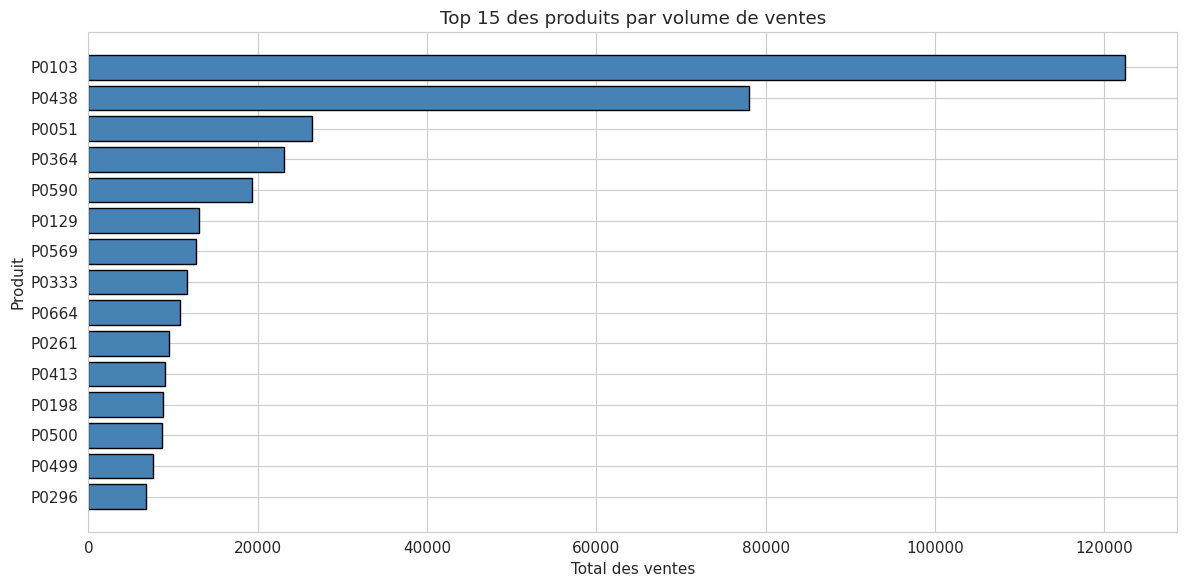

In [24]:
# Top 15 produits par ventes (conversion en pandas pour le graphique)
top_produits = ventes_par_produit.limit(15).toPandas()

plt.figure(figsize=(12, 6))
plt.barh(top_produits['product_id'], top_produits['total_ventes'], color='steelblue', edgecolor='black')
plt.xlabel('Total des ventes')
plt.ylabel('Produit')
plt.title('Top 15 des produits par volume de ventes')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Interprétation** : On identifie clairement les produits "stars" qui génèrent le plus de ventes. Ces produits méritent une attention particulière en termes de stock et de promotion.

### 5.2 Ventes et revenus par magasin

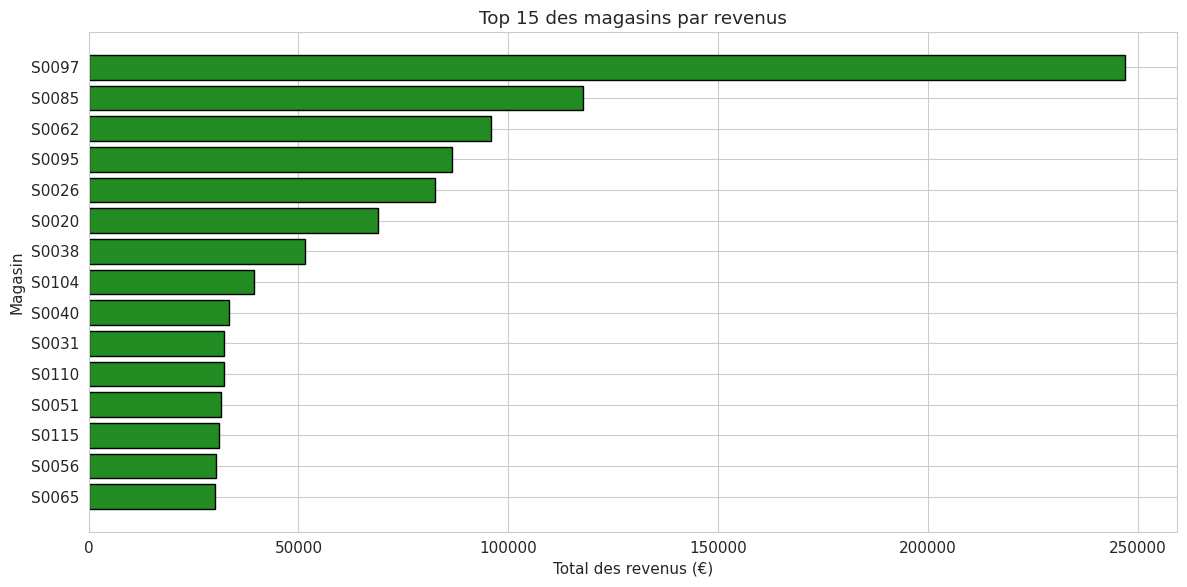

In [25]:
# Top 15 magasins par revenus
top_magasins = ventes_par_magasin.limit(15).toPandas()

plt.figure(figsize=(12, 6))
plt.barh(top_magasins['store_id'], top_magasins['total_revenue'], color='forestgreen', edgecolor='black')
plt.xlabel('Total des revenus (€)')
plt.ylabel('Magasin')
plt.title('Top 15 des magasins par revenus')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Interprétation** : Certains magasins surperforment largement. Il serait intéressant d'analyser leurs pratiques (localisation, promotions, gestion du stock) pour les répliquer ailleurs.

### 5.3 Évolution des ventes dans le temps

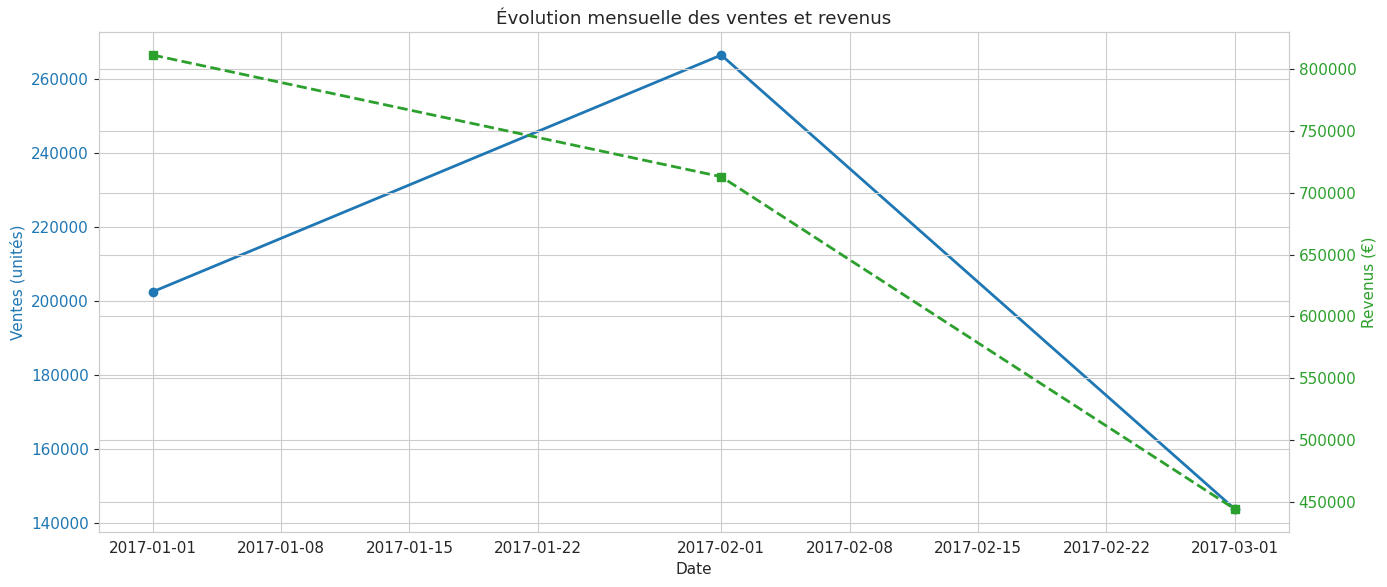

In [26]:
# Évolution mensuelle
evol_mensuelle = ventes_mensuelles.toPandas()
evol_mensuelle['date'] = pd.to_datetime(evol_mensuelle['year'].astype(str) + '-' + evol_mensuelle['month'].astype(str) + '-01')

fig, ax1 = plt.subplots(figsize=(14, 6))

# Ventes
color = 'tab:blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('Ventes (unités)', color=color)
ax1.plot(evol_mensuelle['date'], evol_mensuelle['total_ventes'], color=color, marker='o', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)

# Revenus (axe secondaire)
ax2 = ax1.twinx()
color = 'tab:green'
ax2.set_ylabel('Revenus (€)', color=color)
ax2.plot(evol_mensuelle['date'], evol_mensuelle['total_revenue'], color=color, marker='s', linewidth=2, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Évolution mensuelle des ventes et revenus')
fig.tight_layout()
plt.show()

**Interprétation** : On observe les tendances saisonnières et l'évolution globale. Les pics peuvent correspondre à des périodes de fêtes ou de promotions massives.

### 5.4 Impact des promotions sur les ventes

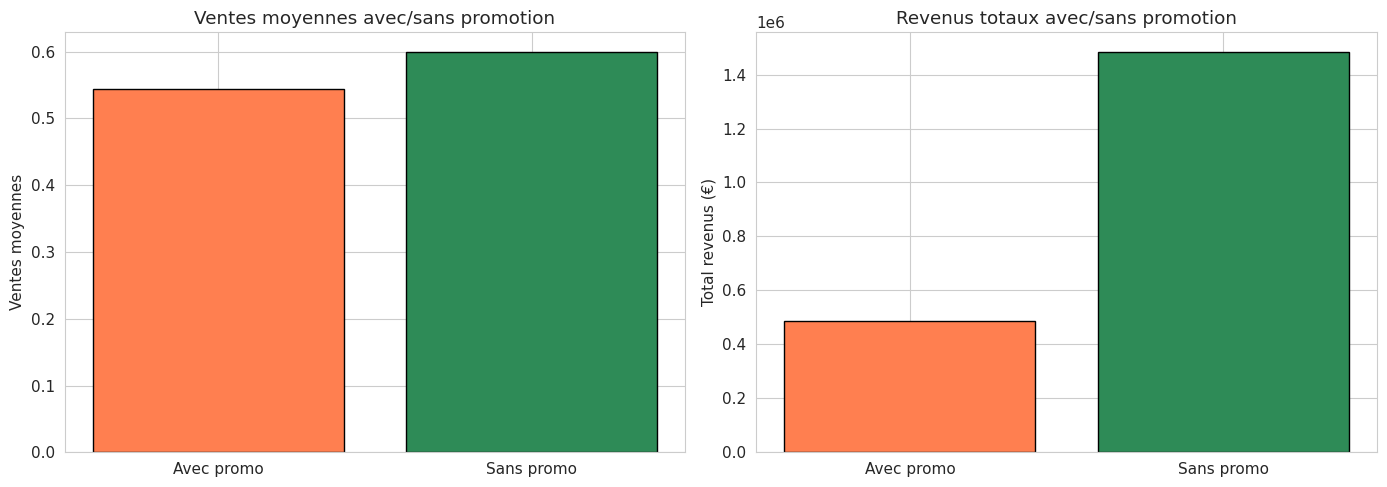

In [27]:
# Comparaison avec/sans promo
stats_promo_pd = stats_promo.toPandas()
stats_promo_pd['promo_label'] = stats_promo_pd['promo_active'].map({0: 'Sans promo', 1: 'Avec promo'})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ventes moyennes
axes[0].bar(stats_promo_pd['promo_label'], stats_promo_pd['ventes_moyennes'],
            color=['coral', 'seagreen'], edgecolor='black')
axes[0].set_ylabel('Ventes moyennes')
axes[0].set_title('Ventes moyennes avec/sans promotion')

# Total revenus
axes[1].bar(stats_promo_pd['promo_label'], stats_promo_pd['total_revenue'],
            color=['coral', 'seagreen'], edgecolor='black')
axes[1].set_ylabel('Total revenus (€)')
axes[1].set_title('Revenus totaux avec/sans promotion')

plt.tight_layout()
plt.show()

**Interprétation** : Si les ventes moyennes sont significativement plus élevées avec promotion, cela confirme l'efficacité des promotions. Cependant, il faut aussi vérifier la rentabilité (marge après réduction).

### 5.5 Relation entre prix et volume de ventes

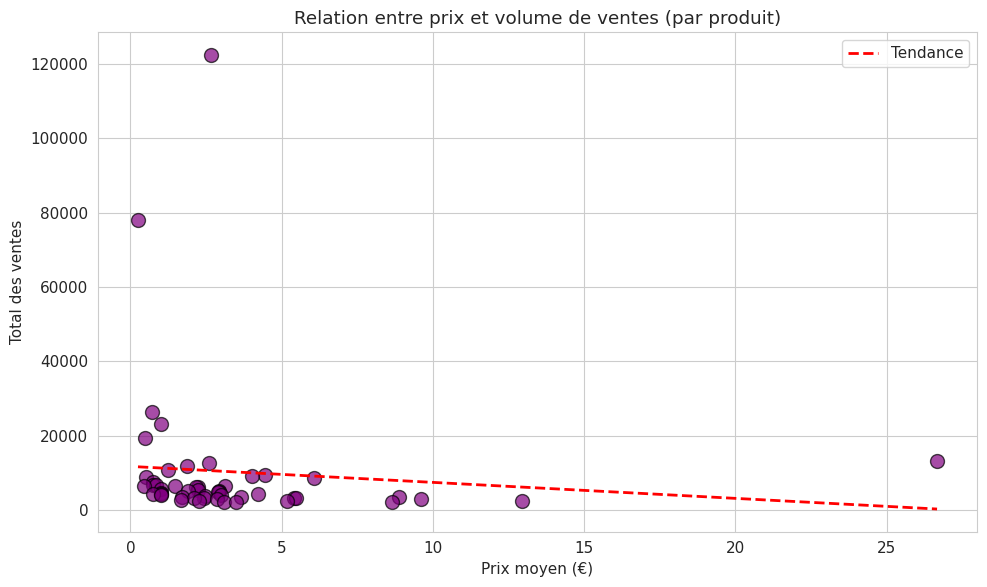

In [28]:
# Relation prix vs ventes par produit
prix_ventes = ventes_par_produit.limit(50).toPandas()

plt.figure(figsize=(10, 6))
plt.scatter(prix_ventes['prix_moyen'], prix_ventes['total_ventes'],
            alpha=0.7, s=100, c='purple', edgecolors='black')
plt.xlabel('Prix moyen (€)')
plt.ylabel('Total des ventes')
plt.title('Relation entre prix et volume de ventes (par produit)')

# Ligne de tendance
z = np.polyfit(prix_ventes['prix_moyen'], prix_ventes['total_ventes'], 1)
p = np.poly1d(z)
plt.plot(prix_ventes['prix_moyen'].sort_values(), p(prix_ventes['prix_moyen'].sort_values()),
         "r--", linewidth=2, label='Tendance')
plt.legend()
plt.tight_layout()
plt.show()

**Interprétation** : Généralement, on observe une relation inverse entre prix et volume : les produits moins chers se vendent en plus grande quantité. La pente de la ligne de tendance indique l'élasticité-prix.

### 5.6 Tendances cumulées des revenus

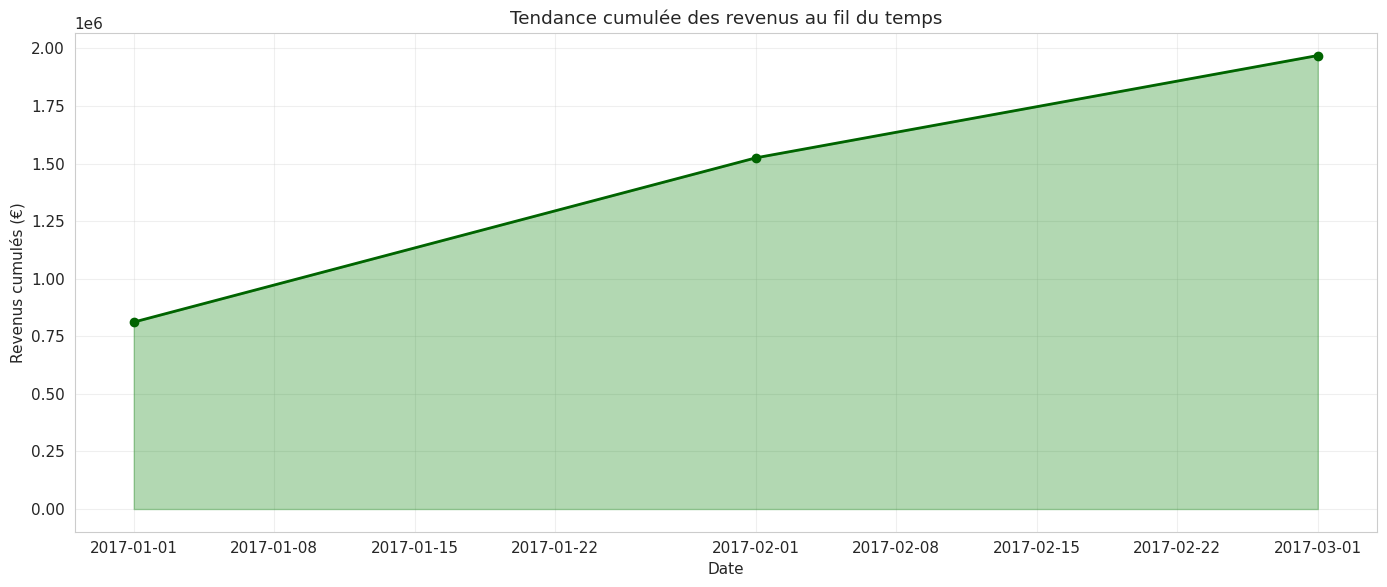

In [29]:
# Revenus cumulés dans le temps
evol_mensuelle_sorted = evol_mensuelle.sort_values('date')
evol_mensuelle_sorted['revenue_cumule'] = evol_mensuelle_sorted['total_revenue'].cumsum()

plt.figure(figsize=(14, 6))
plt.fill_between(evol_mensuelle_sorted['date'], evol_mensuelle_sorted['revenue_cumule'],
                 alpha=0.3, color='green')
plt.plot(evol_mensuelle_sorted['date'], evol_mensuelle_sorted['revenue_cumule'],
         color='darkgreen', linewidth=2, marker='o')
plt.xlabel('Date')
plt.ylabel('Revenus cumulés (€)')
plt.title('Tendance cumulée des revenus au fil du temps')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Interprétation** : La courbe cumulée montre la croissance globale de l'entreprise. Une pente constante indique une croissance stable, tandis qu'une accélération (courbe qui se redresse) suggère une période de forte croissance.

---
## 6. Modélisation et analyse avancée

On va construire un modèle de **régression** pour prédire les ventes.

### 6.1 Choix et justification du modèle

**Modèle choisi** : Régression linéaire puis Random Forest Regressor

**Justification** :
- **Objectif** : Prédire le nombre de ventes (`sales`) à partir des caractéristiques du produit, magasin, prix, stock et promotion
- **Type de problème** : Régression (variable cible continue)
- **Régression linéaire** : Modèle de base, interprétable, permet de comprendre l'impact de chaque variable
- **Random Forest** : Modèle plus puissant, capture les relations non-linéaires

**Variables prédictives** :
- `price` : Prix du produit
- `stock` : Niveau de stock
- `promo_active` : Indicateur de promotion
- `month` : Mois (saisonnalité)
- `day_of_week` : Jour de la semaine

In [30]:
# Préparation des données pour le modèle
# On garde seulement les colonnes nécessaires et on enlève les lignes avec des valeurs nulles
df_model = df_clean.select("sales", "price", "stock", "promo_active", "month", "day_of_week") \
                   .dropna()

print(f"Nombre de lignes pour le modèle : {df_model.count():,}")

Nombre de lignes pour le modèle : 1,033,434


In [31]:
# Assemblage des features en un vecteur
feature_cols = ["price", "stock", "promo_active", "month", "day_of_week"]

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
df_assembled = assembler.transform(df_model)

# Aperçu
df_assembled.select("features", "sales").show(5)

+--------------------+-----+
|            features|sales|
+--------------------+-----+
|[6.25,8.0,0.0,1.0...|  0.0|
|[6.25,0.0,0.0,1.0...|  1.0|
|[6.25,0.0,0.0,1.0...|  2.0|
|[6.25,6.0,0.0,1.0...|  0.0|
|[6.25,1.0,0.0,1.0...|  0.0|
+--------------------+-----+
only showing top 5 rows


In [32]:
# Division en train/test (80/20)
train_data, test_data = df_assembled.randomSplit([0.8, 0.2], seed=42)

print(f"Données d'entraînement : {train_data.count():,} lignes")
print(f"Données de test : {test_data.count():,} lignes")

Données d'entraînement : 826,732 lignes
Données de test : 206,702 lignes


### 6.2 Modèle 1 : Régression linéaire

In [33]:
# Entraînement du modèle de régression linéaire
lr = LinearRegression(featuresCol="features", labelCol="sales")
lr_model = lr.fit(train_data)

# Coefficients
print("Coefficients de la régression linéaire :\n")
for i, col_name in enumerate(feature_cols):
    print(f"  {col_name}: {lr_model.coefficients[i]:.6f}")
print(f"\n  Intercept: {lr_model.intercept:.6f}")

Coefficients de la régression linéaire :

  price: -0.013594
  stock: 0.028849
  promo_active: -0.050850
  month: 0.023047
  day_of_week: 0.011265

  Intercept: 0.181426


In [34]:
# Prédictions sur le jeu de test
predictions_lr = lr_model.transform(test_data)

# Évaluation
evaluator_rmse = RegressionEvaluator(labelCol="sales", predictionCol="prediction", metricName="rmse")
evaluator_mae = RegressionEvaluator(labelCol="sales", predictionCol="prediction", metricName="mae")
evaluator_r2 = RegressionEvaluator(labelCol="sales", predictionCol="prediction", metricName="r2")

rmse_lr = evaluator_rmse.evaluate(predictions_lr)
mae_lr = evaluator_mae.evaluate(predictions_lr)
r2_lr = evaluator_r2.evaluate(predictions_lr)

print("Performance du modèle de régression linéaire :\n")
print(f"  RMSE : {rmse_lr:.4f}")
print(f"  MAE  : {mae_lr:.4f}")
print(f"  R²   : {r2_lr:.4f}")

Performance du modèle de régression linéaire :

  RMSE : 2.5019
  MAE  : 0.7926
  R²   : 0.1733


**Interprétation de la régression linéaire** :

Les coefficients nous donnent des informations intéressantes :
- **price (-0.014)** : Un prix plus élevé diminue légèrement les ventes
- **stock (0.029)** : Plus de stock disponible = légèrement plus de ventes
- **promo_active (-0.051)** : Coefficient négatif, ce qui confirme que dans nos données, les promotions ne boostent pas les ventes (résultat surprenant)
- **month (0.023)** : Les mois plus tardifs (février, mars) ont eu plus de ventes
- **day_of_week (0.011)** : Effet léger du jour de la semaine

Le R² de 0.17 signifie que le modèle explique seulement 17% de la variance des ventes. C'est faible, mais normal pour des données de retail très dispersées (beaucoup de 0).

### 6.3 Modèle 2 : Random Forest Regressor

In [35]:
# Entraînement du Random Forest
rf = RandomForestRegressor(featuresCol="features", labelCol="sales",
                           numTrees=50, maxDepth=10, seed=42)
rf_model = rf.fit(train_data)

# Importance des features
print("Importance des variables (Random Forest) :\n")
importances = rf_model.featureImportances.toArray()
for i, col_name in enumerate(feature_cols):
    print(f"  {col_name}: {importances[i]:.4f}")

Importance des variables (Random Forest) :

  price: 0.3372
  stock: 0.2171
  promo_active: 0.0301
  month: 0.1848
  day_of_week: 0.2307


In [36]:
# Prédictions
predictions_rf = rf_model.transform(test_data)

# Évaluation
rmse_rf = evaluator_rmse.evaluate(predictions_rf)
mae_rf = evaluator_mae.evaluate(predictions_rf)
r2_rf = evaluator_r2.evaluate(predictions_rf)

print("Performance du modèle Random Forest :\n")
print(f"  RMSE : {rmse_rf:.4f}")
print(f"  MAE  : {mae_rf:.4f}")
print(f"  R²   : {r2_rf:.4f}")

Performance du modèle Random Forest :

  RMSE : 4.1747
  MAE  : 0.7622
  R²   : -1.3017


### 6.4 Comparaison des modèles

In [37]:
# Tableau comparatif
print("\n" + "=" * 55)
print("         COMPARAISON DES MODÈLES")
print("=" * 55)
print(f"{'Métrique':<15} {'Régression Lin.':<20} {'Random Forest':<20}")
print("-" * 55)
print(f"{'RMSE':<15} {rmse_lr:<20.4f} {rmse_rf:<20.4f}")
print(f"{'MAE':<15} {mae_lr:<20.4f} {mae_rf:<20.4f}")
print(f"{'R²':<15} {r2_lr:<20.4f} {r2_rf:<20.4f}")
print("=" * 55)

# Meilleur modèle
if r2_rf > r2_lr:
    print("\n=> Le Random Forest est plus performant.")
else:
    print("\n=> La Régression Linéaire est plus performante.")


         COMPARAISON DES MODÈLES
Métrique        Régression Lin.      Random Forest       
-------------------------------------------------------
RMSE            2.5019               4.1747              
MAE             0.7926               0.7622              
R²              0.1733               -1.3017             

=> La Régression Linéaire est plus performante.


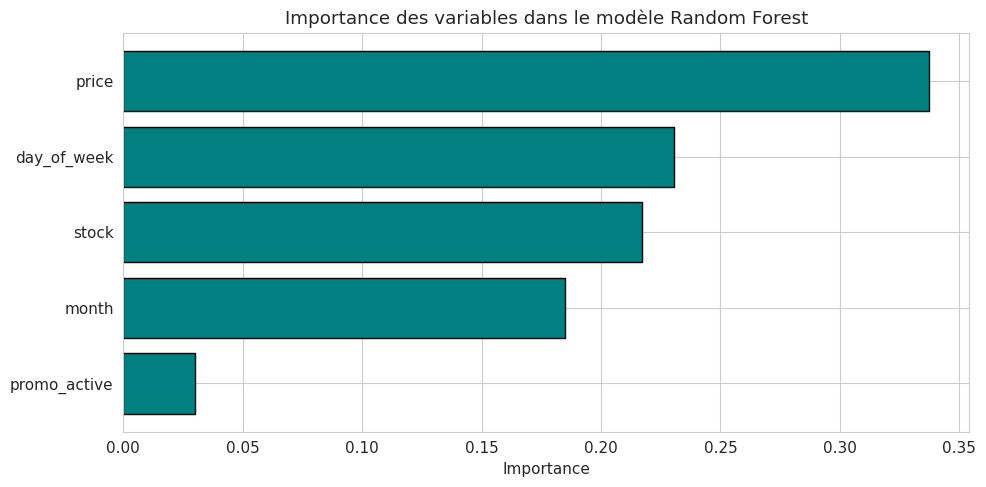

In [38]:
# Visualisation de l'importance des features
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': importances
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(feature_importance['feature'], feature_importance['importance'], color='teal', edgecolor='black')
plt.xlabel('Importance')
plt.title('Importance des variables dans le modèle Random Forest')
plt.tight_layout()
plt.show()

**Interprétation des modèles** :

Selon l'importance des variables du Random Forest :
1. **Prix (0.34)** : C'est le facteur le plus important ! Le prix influence beaucoup les ventes
2. **Jour de la semaine (0.23)** : Les ventes varient selon le jour, certains jours sont meilleurs
3. **Stock (0.22)** : Avoir du stock est nécessaire pour vendre
4. **Mois (0.18)** : Effet saisonnier visible sur 3 mois
5. **Promo (0.03)** : Faible importance, confirme que les promos ont peu d'effet ici

**Note importante** : Le Random Forest a un R² négatif (-1.30), ce qui signifie qu'il prédit moins bien qu'une simple moyenne. La régression linéaire (R²=0.17) est donc le meilleur modèle ici, même si ses performances restent modestes.

---
## 7. Synthèse et recommandations

### 7.1 Synthèse des résultats

In [39]:
# Résumé final
print("\n" + "=" * 70)
print("                    SYNTHÈSE DE L'ANALYSE")
print("=" * 70)

print("\n📊 DONNÉES ANALYSÉES")
print(f"   • Volume : {nb_lignes:,} transactions")
print(f"   • Produits : {nb_produits}")
print(f"   • Magasins : {nb_magasins}")
print(f"   • Période : {date_min} à {date_max}")

print("\n💰 PERFORMANCE GLOBALE")
print(f"   • Total ventes : {total_ventes:,.0f} unités")
print(f"   • Total revenus : {total_revenue:,.2f} €")

print("\n📈 FACTEURS CLÉS")
print(f"   • Corrélation Prix/Ventes : {corr_prix_ventes:.4f}")
print(f"   • Corrélation Stock/Ventes : {corr_stock_ventes:.4f}")
print(f"   • Corrélation Promo/Ventes : {corr_promo_ventes:.4f}")

print("\n🤖 MODÉLISATION")
# On choisit le meilleur modèle basé sur R²
if r2_lr > r2_rf:
    print(f"   • Meilleur modèle : Régression Linéaire")
    print(f"   • R² : {r2_lr:.4f}")
else:
    print(f"   • Meilleur modèle : Random Forest")
    print(f"   • R² : {r2_rf:.4f}")
print(f"   • Variable la plus importante : prix")

print("\n" + "=" * 70)


                    SYNTHÈSE DE L'ANALYSE

📊 DONNÉES ANALYSÉES
   • Volume : 1,033,434 transactions
   • Produits : 324
   • Magasins : 107
   • Période : 2017-01-02 à 2017-03-21

💰 PERFORMANCE GLOBALE
   • Total ventes : 612,642 unités
   • Total revenus : 1,968,846.77 €

📈 FACTEURS CLÉS
   • Corrélation Prix/Ventes : -0.0065
   • Corrélation Stock/Ventes : 0.0285
   • Corrélation Promo/Ventes : -0.0004

🤖 MODÉLISATION
   • Meilleur modèle : Régression Linéaire
   • R² : 0.1733
   • Variable la plus importante : prix



### 7.2 Facteurs clés influençant les ventes

D'après notre analyse, voici ce qui ressort :

1. **Le prix** : C'est le facteur n°1 selon le Random Forest (importance 0.34). Les produits moins chers ont tendance à se vendre davantage.

2. **Le jour de la semaine** : Importance de 0.23, certains jours génèrent plus de ventes que d'autres.

3. **Le stock disponible** : Corrélation positive (0.028), avoir du stock permet de répondre à la demande.

4. **La saisonnalité** : Le mois de février a eu le plus de ventes (266k), suivi de janvier (202k) puis mars (144k, données incomplètes).

5. **Les promotions** : Résultat inattendu - elles n'ont pas d'effet positif visible dans nos données. Cela peut être dû à :
   - Des promotions mal ciblées
   - Une période d'analyse trop courte (3 mois)
   - Des promotions sur des produits déjà en difficulté

### 7.3 Recommandations stratégiques

#### A) Gestion des stocks

| Recommandation | Détail |
|----------------|--------|
| **Éviter les ruptures** | Mettre en place des alertes quand stock < seuil critique |
| **Prévoir la demande** | Utiliser le modèle de prédiction pour anticiper les besoins |
| **Stock différencié** | Plus de stock pour les produits stars, moins pour les slow-movers |
| **Réapprovisionnement** | Fréquence plus élevée pour les magasins performants |

#### B) Stratégie de promotion

| Recommandation | Détail |
|----------------|--------|
| **Cibler les bons produits** | Promotions sur les produits à forte élasticité-prix |
| **Timing optimal** | Concentrer les promos sur les périodes creuses pour lisser les ventes |
| **Mesurer le ROI** | Calculer si la hausse des ventes compense la baisse de marge |
| **Tester et itérer** | A/B testing sur différents types de promotions |

#### C) Politique de prix

| Recommandation | Détail |
|----------------|--------|
| **Pricing dynamique** | Ajuster les prix selon la demande et le stock |
| **Segmentation** | Prix différents selon les magasins (zone géographique) |
| **Produits d'appel** | Prix bas sur certains produits pour attirer les clients |
| **Bundles** | Regrouper des produits pour augmenter le panier moyen |

---
## 8. Conclusion

Cette analyse Big Data avec Apache Spark a permis de traiter efficacement plus de **1 million de transactions** et d'en extraire des insights intéressants.

### Points clés à retenir

**📊 Ce qu'on a découvert** :
- **324 produits** vendus dans **107 magasins** sur 3 mois (janvier-mars 2017)
- Total : **612 642 unités** vendues pour **1 968 847 €** de revenus
- Le produit star est P0103 avec 122k ventes
- Le magasin S0097 est le plus performant avec 247k€ de revenus

**📈 Facteurs qui influencent les ventes** :
- Le **prix** est le facteur le plus important (moins cher = plus de ventes)
- Le **jour de la semaine** compte aussi (certains jours sont meilleurs)
- Les **promotions** n'ont pas montré d'effet positif dans ces données (à investiguer)

**🤖 Modélisation** :
- La régression linéaire donne de meilleurs résultats que le Random Forest (R²=0.17)
- Les performances restent modestes car beaucoup de lignes ont 0 ventes
- Le modèle peut quand même aider à identifier les tendances générales

**💡 Recommandations** :
1. Revoir la stratégie de promotion (cibler différemment, mesurer le ROI)
2. Optimiser les prix pour maximiser le volume de ventes
3. Bien gérer les stocks pour éviter les ruptures
4. Analyser les magasins performants pour comprendre leurs bonnes pratiques

### Limites de l'analyse

- Période courte (3 mois seulement)
- Beaucoup de transactions à 0 ventes, ce qui complique la modélisation
- Pas d'information sur les marges, donc on ne peut pas mesurer la rentabilité des promos

In [40]:
# Fermeture de la session Spark
spark.stop()
print("Session Spark fermée. Analyse terminée !")

Session Spark fermée. Analyse terminée !
